In [139]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns

Connecting to the database

In [140]:
# Connect to the SQLite database
engine = create_engine('sqlite:///ShiftData.db')
# See what tables are in the database
with engine.connect() as connection:
    result = connection.exec_driver_sql("SELECT name FROM sqlite_master WHERE type='table';")
    tables = result.fetchall()
    print("Tables in the database:", tables)

Tables in the database: [('ShiftPerformance',)]


There is only one table in the database

In [141]:
# load the data from the database into a pandas DataFrame
with engine.connect() as connection:
    df = pd.read_sql("SELECT * FROM ShiftPerformance", connection)

In [142]:
df.to_csv('data/ShiftPerformance.csv', index=False)

In [143]:
df_copy = df.copy()

In [144]:
df.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [145]:
df.shape

(296334, 31)

In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296334 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   shift_id                296334 non-null  int64  
 1   shift_name              296334 non-null  object 
 2   start_time              296334 non-null  object 
 3   end_time                296334 non-null  object 
 4   supervisor_id           296334 non-null  object 
 5   production_id           296334 non-null  int64  
 6   date                    296334 non-null  object 
 7   units_produced          296334 non-null  int64  
 8   defect_count            296334 non-null  int64  
 9   cycle_time_avg          296334 non-null  float64
 10  shift_efficiency_score  296334 non-null  float64
 11  operator_id             296334 non-null  object 
 12  operator_name           296334 non-null  object 
 13  experience_level        296334 non-null  int64  
 14  skill_category      

The data shows a lot of data types that are not consistent with the columns. Dates as integers or floats, different types of IDs as well as categorical variables.

In [147]:
# check the time range of the data
df['timestamp'] = pd.to_datetime(df['timestamp'])
print("Time range of the data:", df['timestamp'].min(), "to", df['timestamp'].max())

Time range of the data: 2024-01-01 08:00:00 to 2024-03-31 16:00:00


In [148]:
df['shift_efficiency_score'].head()

0    95.945255
1    95.945255
2    95.945255
3    95.945255
4    95.945255
Name: shift_efficiency_score, dtype: float64

### Data Cleaning

In [149]:
df.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            181103
issue_type                181103
maintenance_downtime      181103
resolved_by               181103
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                 1205
humidity                    1205
timestamp 

In [150]:
# drop rows with missing values in the 'temperature' column
df.dropna(subset=['temperature'], inplace=True)

In [151]:
df.shape

(295129, 31)

In [152]:
df.isna().sum()

shift_id                       0
shift_name                     0
start_time                     0
end_time                       0
supervisor_id                  0
production_id                  0
date                           0
units_produced                 0
defect_count                   0
cycle_time_avg                 0
shift_efficiency_score         0
operator_id                    0
operator_name                  0
experience_level               0
skill_category                 0
machine_id                     0
runtime_hours                  0
downtime_minutes               0
maintenance_flag               0
machine_status                 0
maintenance_id            180370
issue_type                180370
maintenance_downtime      180370
resolved_by               180370
qc_id                          0
defect_type                    0
severity                       0
inspection_result              0
temperature                    0
humidity                       0
timestamp 

In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295129 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                295129 non-null  int64         
 1   shift_name              295129 non-null  object        
 2   start_time              295129 non-null  object        
 3   end_time                295129 non-null  object        
 4   supervisor_id           295129 non-null  object        
 5   production_id           295129 non-null  int64         
 6   date                    295129 non-null  object        
 7   units_produced          295129 non-null  int64         
 8   defect_count            295129 non-null  int64         
 9   cycle_time_avg          295129 non-null  float64       
 10  shift_efficiency_score  295129 non-null  float64       
 11  operator_id             295129 non-null  object        
 12  operator_name           295129 non-

In [156]:
# correction of data types if necessary
# normalize time strings like "06:00:00.0000000" -> "06:00:00"
for col in ['start_time', 'end_time']:
    df[col] = df[col].astype(str).str.replace(r'\.\d+$', '', regex=True)

df['start_time'] = pd.to_datetime(df['start_time'], format='%H:%M:%S', errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], format='%H:%M:%S', errors='coerce')
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295129 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                295129 non-null  int64         
 1   shift_name              295129 non-null  object        
 2   start_time              295129 non-null  datetime64[ns]
 3   end_time                295129 non-null  datetime64[ns]
 4   supervisor_id           295129 non-null  object        
 5   production_id           295129 non-null  int64         
 6   date                    295129 non-null  datetime64[ns]
 7   units_produced          295129 non-null  int64         
 8   defect_count            295129 non-null  int64         
 9   cycle_time_avg          295129 non-null  float64       
 10  shift_efficiency_score  295129 non-null  float64       
 11  operator_id             295129 non-null  object        
 12  operator_name           295129 non-

In [157]:
# showing the different type of the categorical columns
print("Unique Operators:", df['operator_name'].nunique(), df['operator_id'].unique())
print("=" * 100)
print("Experience Levels:", df['experience_level'].nunique(), np.sort(df['experience_level'].unique()))
print("=" * 100)
print("Skill Category:", df['skill_category'].nunique(), np.sort(df['skill_category'].unique()))
print("=" * 100)
print("Issue Types:", df['issue_type'].nunique(), df['issue_type'].unique())
print("=" * 100)
print("Resolved by Shift:", df['resolved_by'].nunique(), df['resolved_by'].unique())
print("=" * 100)
print("Maintenance Flags", df['maintenance_flag'].nunique(), np.sort(df['maintenance_flag'].unique()))
print("=" * 100)
print("Defect Types:", df['defect_type'].nunique(), df['defect_type'].unique())
print("=" * 100)
print("Severity Levels:", df['severity'].nunique(), df['severity'].unique())
print("=" * 100)
print("Inspection result:", df['inspection_result'].nunique(), df['inspection_result'].unique())

Unique Operators: 110 ['OP_019' 'OP_033' 'OP_069' 'OP_090' 'OP_051' 'OP_119' 'OP_068' 'OP_014'
 'OP_078' 'OP_048' 'OP_041' 'OP_026' 'OP_102' 'OP_037' 'OP_081' 'OP_012'
 'OP_049' 'OP_044' 'OP_052' 'OP_032' 'OP_053' 'OP_115' 'OP_013' 'OP_084'
 'OP_076' 'OP_001' 'OP_063' 'OP_105' 'OP_004' 'OP_008' 'OP_118' 'OP_074'
 'OP_080' 'OP_096' 'OP_002' 'OP_021' 'OP_045' 'OP_015' 'OP_009' 'OP_073'
 'OP_005' 'OP_067' 'OP_047' 'OP_010' 'OP_098' 'OP_066' 'OP_117' 'OP_016'
 'OP_020' 'OP_097' 'OP_017' 'OP_003' 'OP_006' 'OP_022' 'OP_113' 'OP_094'
 'OP_104' 'OP_116' 'OP_050' 'OP_055' 'OP_060' 'OP_018' 'OP_065' 'OP_114'
 'OP_007' 'OP_042' 'OP_120' 'OP_043' 'OP_036' 'OP_087' 'OP_112' 'OP_025'
 'OP_057' 'OP_106' 'OP_061' 'OP_028' 'OP_108' 'OP_070' 'OP_099' 'OP_030'
 'OP_092' 'OP_039' 'OP_088' 'OP_100' 'OP_031' 'OP_071' 'OP_059' 'OP_029'
 'OP_086' 'OP_024' 'OP_079' 'OP_023' 'OP_046' 'OP_089' 'OP_091' 'OP_054'
 'OP_040' 'OP_101' 'OP_038' 'OP_110' 'OP_027' 'OP_107' 'OP_075' 'OP_103'
 'OP_082' 'OP_034' 'OP_035' '

In [158]:
df.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,...,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp
0,1,Morning,1900-01-01 06:00:00,1900-01-01 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
1,1,Morning,1900-01-01 06:00:00,1900-01-01 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00
2,1,Morning,1900-01-01 06:00:00,1900-01-01 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
3,1,Morning,1900-01-01 06:00:00,1900-01-01 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00
4,1,Morning,1900-01-01 06:00:00,1900-01-01 14:00:00,SUP_01,1,2024-01-01,929,20,35.65,...,None,NaN,None,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00


Checking for outliers

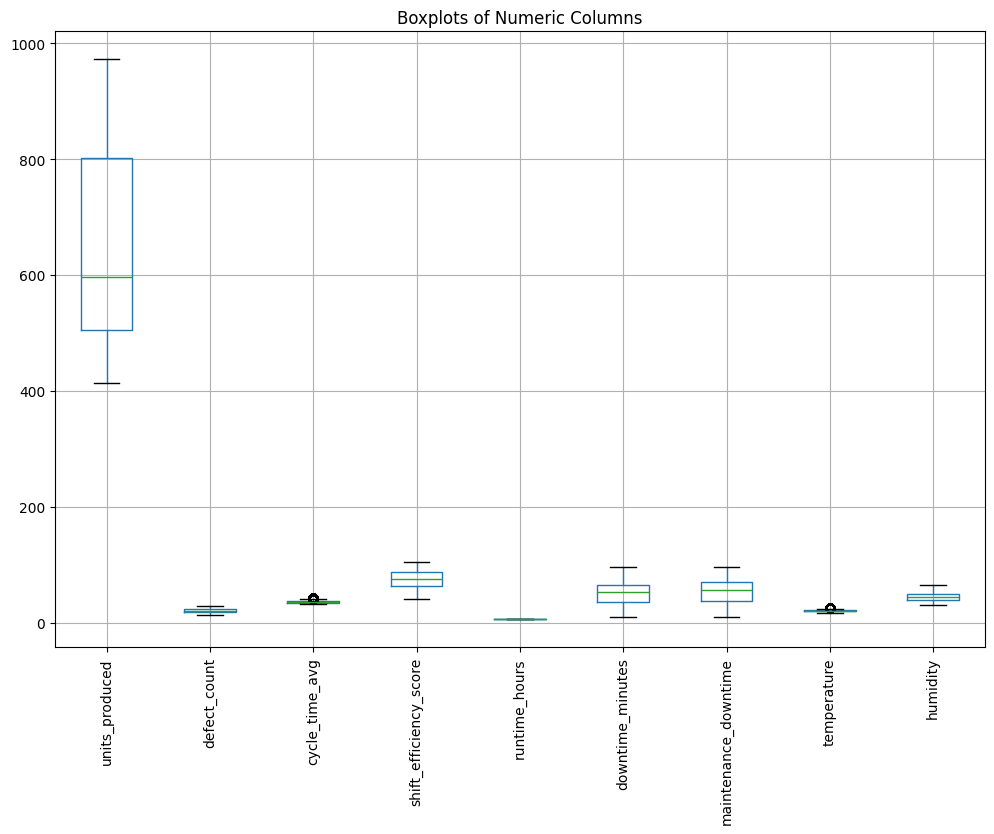

In [159]:
numeric_cols = ['units_produced', 'defect_count', 'cycle_time_avg', 
                'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 
                'maintenance_downtime', 'temperature', 'humidity']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot(rot=90)
plt.title('Boxplots of Numeric Columns')
plt.show()

The boxplot shows the cycle time avg and temperature both have outliers.

Winsorization can be used to handle the outliers

Getting outlier values

In [160]:
def get_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    return mask

iqr_outliers = pd.DataFrame()

for col in numeric_cols:
    iqr_outliers[col] = get_iqr_outliers(df, col)

print(iqr_outliers.sum())

units_produced               0
defect_count                 0
cycle_time_avg            1264
shift_efficiency_score       0
runtime_hours                0
downtime_minutes             0
maintenance_downtime         0
temperature               1216
humidity                     0
dtype: int64


Fixing outliers

In [161]:
def winsorize(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

In [162]:
outlier_cols = iqr_outliers.columns[iqr_outliers.sum() > 0]
print("Columns with outliers:", outlier_cols)
for col in outlier_cols:
    df = winsorize(df, col)
print("Outliers have been winsorized in columns:", outlier_cols)

Columns with outliers: Index(['cycle_time_avg', 'temperature'], dtype='object')
Outliers have been winsorized in columns: Index(['cycle_time_avg', 'temperature'], dtype='object')


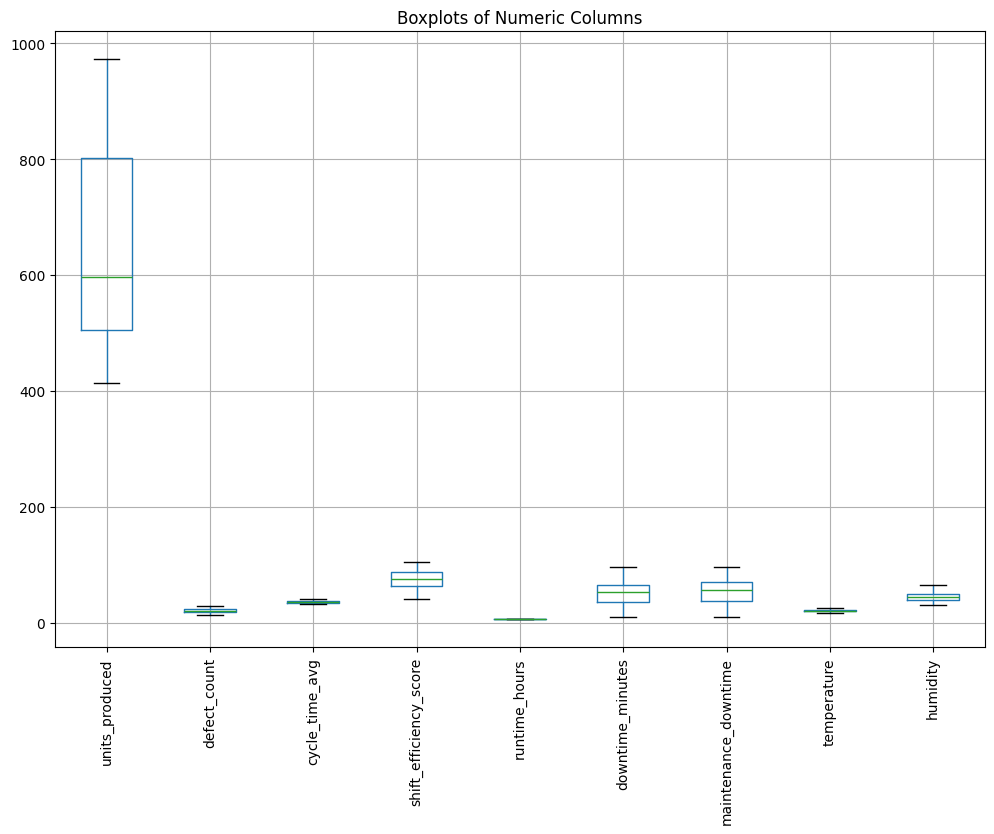

In [163]:
numeric_cols = ['units_produced', 'defect_count', 'cycle_time_avg', 
                'shift_efficiency_score', 'runtime_hours', 'downtime_minutes', 
                'maintenance_downtime', 'temperature', 'humidity']

plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot(rot=90)
plt.title('Boxplots of Numeric Columns')
plt.show()

### Feature Engineering

In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 295129 entries, 0 to 296333
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   shift_id                295129 non-null  int64         
 1   shift_name              295129 non-null  object        
 2   start_time              295129 non-null  datetime64[ns]
 3   end_time                295129 non-null  datetime64[ns]
 4   supervisor_id           295129 non-null  object        
 5   production_id           295129 non-null  int64         
 6   date                    295129 non-null  datetime64[ns]
 7   units_produced          295129 non-null  int64         
 8   defect_count            295129 non-null  int64         
 9   cycle_time_avg          295129 non-null  float64       
 10  shift_efficiency_score  295129 non-null  float64       
 11  operator_id             295129 non-null  object        
 12  operator_name           295129 non-

In [165]:
# Feature engineering: create new features based on existing ones
#Output per hour
shift_summary = df.groupby('production_id').agg({
    'units_produced': 'max',
    'defect_count': 'first',
    'start_time': 'first',
    'end_time': 'first'
})

shift_duration = shift_summary['end_time'] - shift_summary['start_time']
shift_duration = shift_duration.where(
    shift_duration >= pd.Timedelta(0),
    shift_duration + pd.Timedelta(days=1)
)

shift_summary['output_per_hour'] = (
    shift_summary['units_produced'] / (shift_duration.dt.total_seconds() / 3600)
)

df['output_per_hour'] = df['production_id'].map(shift_summary['output_per_hour'])

# efficiency index: ratio of actual output to maximum output per hour across all shifts
df['efficiency_index'] = df['output_per_hour'] / df['output_per_hour'].max()

# defect rate: ratio of defective units to total units produced
df['defect_rate'] = df['defect_count'] / df['units_produced'].replace(0, np.nan)

# OEE (Overall Equipment Efficiency): Combine machine availability, performance, and quality into one score.
df['oee'] = (df['runtime_hours'] / (df['runtime_hours'] + df['downtime_minutes'] / 60)) * \
            (df['output_per_hour'] / df['output_per_hour'].max()) * \
            (1 - df['defect_rate'])

In [166]:
df[['output_per_hour','efficiency_index', 'defect_rate', 'oee']]

,output_per_hour,efficiency_index,defect_rate,oee
0,116.125,0.955761,0.021529,0.903187
1,116.125,0.955761,0.021529,0.903187
2,116.125,0.955761,0.021529,0.903187
3,116.125,0.955761,0.021529,0.903187
4,116.125,0.955761,0.021529,0.903187
...,...,...,...,...
296329,63.750,0.524691,0.039216,0.418089
296330,63.750,0.524691,0.039216,0.418089
296331,63.750,0.524691,0.039216,0.418089
296332,63.750,0.524691,0.039216,0.418089


### Exploratory Data Analysis

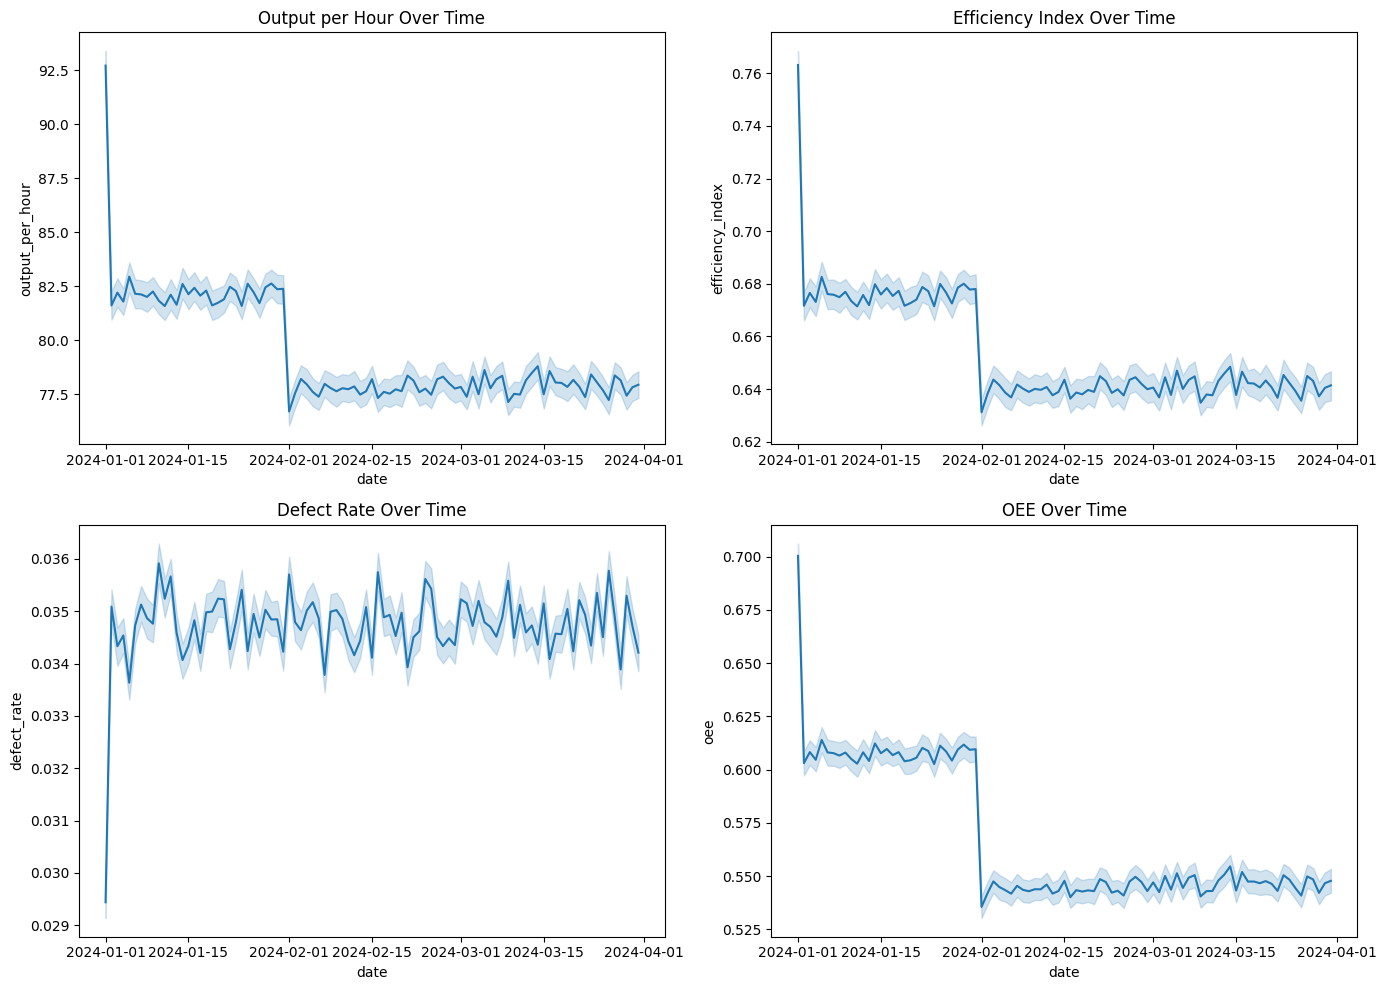

In [167]:
# visualize shift trends with multiple metrics
plt.figure(figsize=(14, 10))
plt.subplot(2, 2, 1)
sns.lineplot(data=df, x='date', y='output_per_hour')
plt.title('Output per Hour Over Time')
plt.subplot(2, 2, 2)
sns.lineplot(data=df, x='date', y='efficiency_index')
plt.title('Efficiency Index Over Time')
plt.subplot(2, 2, 3)
sns.lineplot(data=df, x='date', y='defect_rate')
plt.title('Defect Rate Over Time')
plt.subplot(2, 2, 4)
sns.lineplot(data=df, x='date', y='oee')
plt.title('OEE Over Time')
plt.tight_layout()

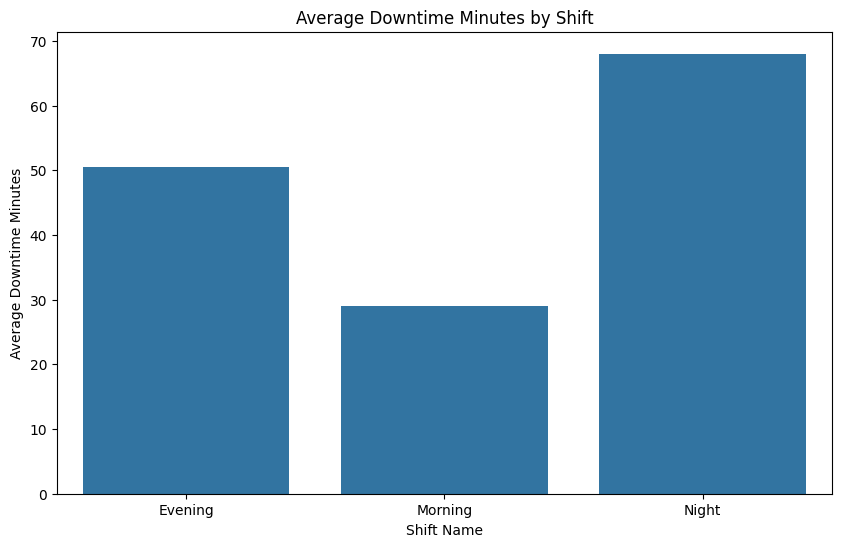

In [168]:
# distrubution of downtime across shifts
shifts_downtime = df.groupby('shift_name').agg({'downtime_minutes': 'mean'}).reset_index()
shifts_downtime
plt.figure(figsize=(10, 6))
plt.subplot(1, 1, 1)
sns.barplot(data=shifts_downtime, x='shift_name', y='downtime_minutes')
plt.title('Average Downtime Minutes by Shift')
plt.xlabel('Shift Name')
plt.ylabel('Average Downtime Minutes')
plt.show()

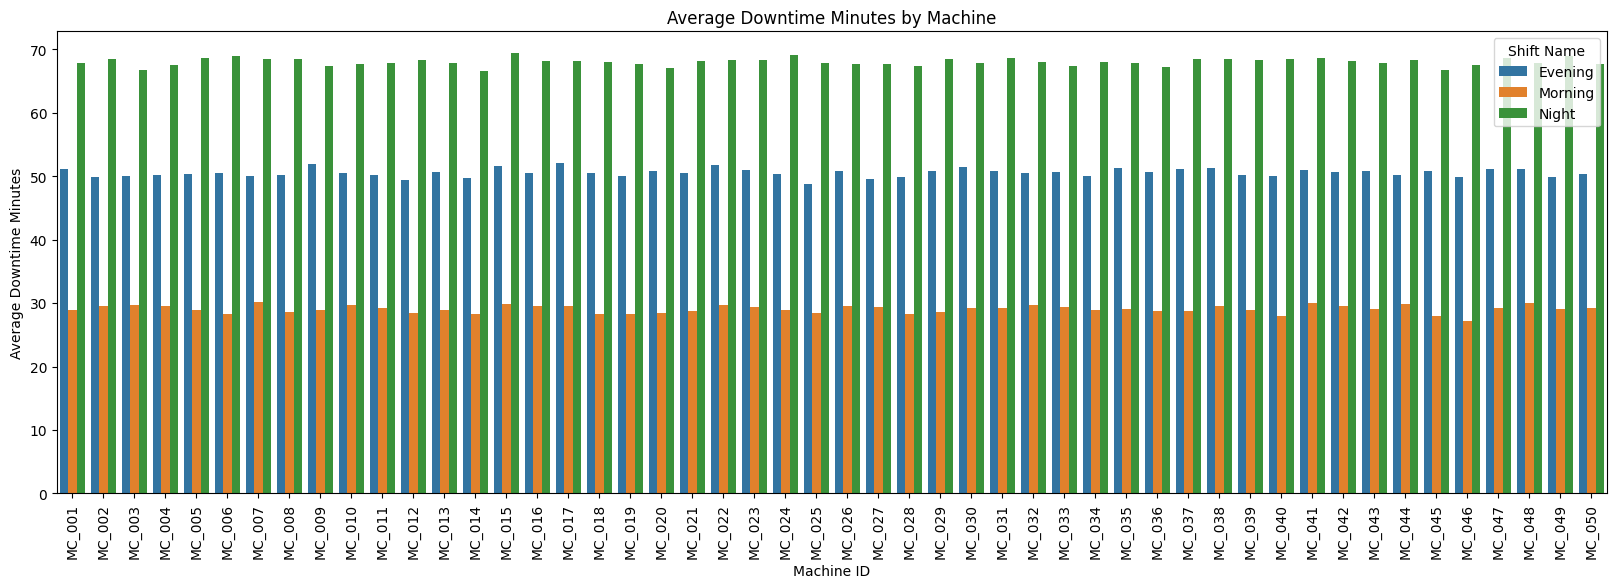

In [173]:
machine_availability = df.groupby(['machine_id', 'shift_name']).agg({'downtime_minutes': 'mean'}).reset_index()
machine_availability
plt.figure(figsize=(20, 6))
sns.barplot(data=machine_availability, x='machine_id', y='downtime_minutes', hue='shift_name')
plt.xticks(rotation=90)
plt.title('Average Downtime Minutes by Machine')
plt.xlabel('Machine ID')
plt.ylabel('Average Downtime Minutes')
plt.legend(title='Shift Name')
plt.show()


# plt.figure(figsize=(10, 6))
